In [ ]:
from pydantic import BaseModel, Field

from langgraph.graph import StateGraph, START, END
from langgraph.prebuilt import ToolNode

from langchain_core.messages import AIMessage, ToolMessage
from langchain_core.messages import convert_to_messages, convert_to_openai_messages

from jinja2 import Template
from typing import Literal, Dict, Any, Annotated, List
from IPython.display import Image, display
from operator import add

import random
import ast
import inspect
import instructor
import json
import anthropic


from utils.utils import get_tool_descriptions, make_message_langchain_compatible

### Single node graph
What a node really is?
Since every graph has a state these should be some initial state

In [32]:
# Schema for state
class State(BaseModel):
        message: str
        answer: str = ""
        vibe: str

In [33]:
def append_vibes_to_query(state: State) -> dict:
        return {
                "answer": f"{state.message} {state.vibe}"
        }

In [34]:
# pass the initial State
workflow = StateGraph(State)

# Crete the first node
workflow.add_node("append_vibes_to_query", append_vibes_to_query)

# add edges to special nodes
workflow.add_edge(START, "append_vibes_to_query")
workflow.add_edge("append_vibes_to_query", END)

graph = workflow.compile()


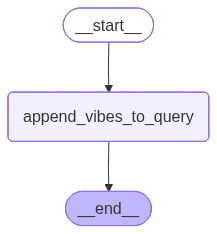

In [35]:
display(Image(graph.get_graph().draw_mermaid_png()))

In [41]:
# run the graph
initial_state = {
        "message": "Give me some vobes",
        "answer": "initial answer",
        "vibe": "I'm feeling like a badass today!"
}

In [42]:
# here the state evolves
result = graph.invoke(initial_state)

In [43]:
# result will have 3 keys, 2 we defined
# answer is being overwritten from the graph execution
result


{'message': 'Give me some vobes',
 'answer': "Give me some vobes I'm feeling like a badass today!",
 'vibe': "I'm feeling like a badass today!"}

### Conditional Graph

In [60]:
# Schema for state
class State(BaseModel):
        message: str
        answer: str = ""

In [11]:
def append_vibes_to_query(state: State) -> dict:
        return {
                "answer": "My vibe today:"
        }

def router(state: State) -> Literal["vibe_1", "vibe_2", "vibe_3"]:
        vibes = ["vibe_1", "vibe_2", "vibe_3"]
        return random.choice(vibes)

def append_vibe_1(state: State) -> dict:
        vibe = "Legend"
        return {
                "answer": f"{state.answer} {vibe}"
        }

def append_vibe_2(state: State) -> dict:
        vibe = "Superstar"
        return {
                "answer": f"{state.answer} {vibe}"
        }

def append_vibe_3(state: State) -> dict:
        vibe = "Boss"
        return {
                "answer": f"{state.answer} {vibe}"
        }

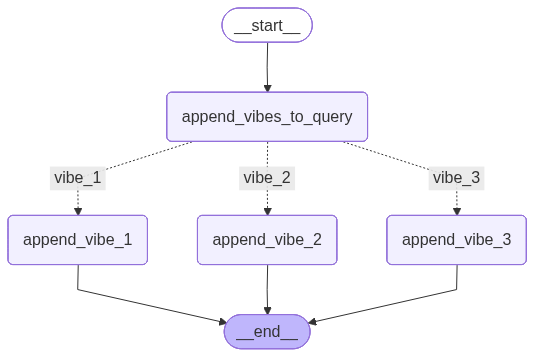

In [66]:
# pass the initial State
workflow = StateGraph(State)

# Crete the nodes
workflow.add_node("append_vibes_to_query", append_vibes_to_query)
workflow.add_node("append_vibe_1", append_vibe_1)
workflow.add_node("append_vibe_2", append_vibe_2)
workflow.add_node("append_vibe_3", append_vibe_3)

# START NODE
workflow.add_edge(START, "append_vibes_to_query")
# the EDGE is a conditional edge
workflow.add_conditional_edges(
        source = "append_vibes_to_query",
        path = router,
        path_map = {
                "vibe_1": "append_vibe_1",
                "vibe_2": "append_vibe_2",
                "vibe_3": "append_vibe_3",
        }
)
# END NODE
workflow.add_edge("append_vibe_1", END)
workflow.add_edge("append_vibe_2", END)
workflow.add_edge("append_vibe_3", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [72]:
initial_state = {
        "message": "Give me some vibes", # not used
        "answer": "initial answer",
}
result = graph.invoke(initial_state)
result

{'message': 'Give me some vibes', 'answer': 'My vibe today: Legend'}

### Agent Graph
Graph that can call tools/LLM

In [12]:
# tool
"""
Good tool will have
- good name
- parameters with type hint
- output type hint
- proper docstring
- Args properly defined
- proper return description

"""
def append_vibes(query: str, vibe: str) -> str:
        """
        Takes in a query and vibe and returns a string with query and vibe appended

        Args:
                query: The query to append the vibe to
                vibe: The vibe to append to the query
        
        Returns:
                A string with the query and vibe appended
        """

        return f"{query} {vibe}"

In [ ]:
get_tool_descriptions([append_vibes])

[{'name': 'append_vibes',
  'description': 'Takes in a query and vibe and returns a string with query and vibe appended',
  'parameters': {'type': 'object',
   'properties': {'query': {'type': 'string',
     'description': 'The query to append the vibe to'},
    'vibe': {'type': 'string',
     'description': 'The vibe to append to the query'}}},
  'required': ['query', 'vibe'],
  'returns': {'type': 'string',
   'description': 'A string with the query and vibe appended'}}]

In [23]:
"""
messages — the conversation history (user messages, AI messages, tool results). This is the one to pay attention to, explained below.
message — likely the current/incoming user input being processed this turn.
iteration — a loop counter. Since agents loop (reason → call tool → reason again), this tracks how many cycles have happened, typically used to enforce a maximum so the agent can't loop forever.
answer — the final response text, filled in once the agent is done reasoning.
available_tools — the list of tool schemas the agent can choose from. This is exactly the output of get_tool_descriptions from your earlier screenshots—the JSON-schema descriptions handed to the LLM so it knows what tools exist.
tool_calls — the tool requests the model produced this turn, typed as a list of the ToolCall model above, ready to be executed.
"""


class ToolCall(BaseModel):
        name: str
        aruguments: dict

class State(BaseModel):
        messages: Annotated[List[Any], add] = []
        message: str = ""
        iteration: int = 0
        answer: str = ""
        available_tools: List[Dict[str, Any]] = []
        tool_calls: List[ToolCall] = []

class AgentResponse(BaseModel):
        answer: str
        tool_calls: List[ToolCall] = Field(default_factory=list)


In [ ]:
# an agent node which can call LLM using prompt
def agent_node(state: State) -> dict:

        prompt_template = """
                You are an assistant that is generating vibes for a user.

                You will be given a selection of tools you can use to add vibes to a user's query.
                <Available tools>
                {{ available_tools | tojson }}
                </Available tools>

                When you need to use a tool, format your response as:
                <tool_call>
                {"name": "tool_name", "arguments": {...}}
                </tool_call>

                Instructions:
                - You need to use the tools to add vibes to the user's query.
                - Add a random vibe to the user's query.
        """

        template = Template(prompt_template)

        prompt = template.render(
                available_tools=state.available_tools
        )

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())

        # since we have response_model, it will always give us output which is compatible to 'format_ai_message'
        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=AgentResponse,
                max_tokens=8096,
                system=prompt,
                messages=[
                        {"role": "user", "content": state.message}
                ],
                temperature=0.5,
                
        )
        
        # langGraph compatiple message
        ai_message = make_message_langchain_compatible(response)

        return {
                "messages": [ai_message],
                "tool_calls": response.tool_calls
        }

In [37]:
def tool_router(state: State) -> str:
        """Decide wheater to continue or end"""
        if len(state.tool_calls) > 0:
                return "tools"
        return "end"

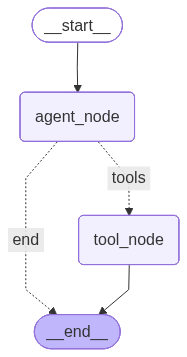

In [ ]:
# pass the initial State
workflow = StateGraph(State)

tools = [append_vibes]

# a ToolNode execute the last tools requested in state.messages (its langgraph property)
# and append result to the messages array itself
tool_node = ToolNode(tools)

# Crete the nodes
workflow.add_node("agent_node", agent_node)
workflow.add_node("tool_node", tool_node)

# START NODE
workflow.add_edge(START, "agent_node")
# the EDGE is a conditional edge
workflow.add_conditional_edges(
        source = "agent_node",
        path = tool_router,
        path_map = {
                "tools": "tool_node",
                "end": END,
        }
)
# END NODE
workflow.add_edge("tool_node", END)

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [42]:
tool_description = get_tool_descriptions(tools)
initial_state = {
        "message": "My vibe is what: ",
        "available_tools": tool_description,
}
result = graph.invoke(initial_state)
result

prompt 
                You are an assistant that is generating vibes for a user.

                You will be given a selection of tools you can use to add vibes to a user's query.
                <Available tools>
                [{"description": "Takes in a query and vibe and returns a string with query and vibe appended", "name": "append_vibes", "parameters": {"properties": {"query": {"description": "The query to append the vibe to", "type": "string"}, "vibe": {"description": "The vibe to append to the query", "type": "string"}}, "type": "object"}, "required": ["query", "vibe"], "returns": {"description": "A string with the query and vibe appended", "type": "string"}}]
                </Available tools>

                When you need to use a tool, format your response as:
                <tool_call>
                {"name": "tool_name", "arguments": {...}}
                </tool_call>

                Instructions:
                - You need to use the tools to add vibes to the us

{'messages': [AIMessage(content='Let me add some vibes to that question for you!', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'My vibe is what', 'vibe': '✨ cosmic energy meets mysterious intrigue ✨'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='My vibe is what ✨ cosmic energy meets mysterious intrigue ✨', name='append_vibes', tool_call_id='call_0')],
 'message': 'My vibe is what: ',
 'available_tools': [{'name': 'append_vibes',
   'description': 'Takes in a query and vibe and returns a string with query and vibe appended',
   'parameters': {'type': 'object',
    'properties': {'query': {'type': 'string',
      'description': 'The query to append the vibe to'},
     'vibe': {'type': 'string',
      'description': 'The vibe to append to the query'}}},
   'required': ['query', 'vibe'],
   'returns': {'type': 'string',
    'description': 'A string with the query and vibe appended'}}],
 'tool_c

# ReAct Agent
### i.e. Agent graph with loopback from tools

In [46]:
class ToolCall(BaseModel):
        name: str
        aruguments: dict

class State(BaseModel):
        messages: Annotated[List[Any], add] = []
        message: str = ""
        iteration: int = 0
        answer: str = ""
        available_tools: List[Dict[str, Any]] = []
        tool_calls: List[ToolCall] = []

class AgentResponse(BaseModel):
        answer: str
        tool_calls: List[ToolCall] = Field(default_factory=list)



def append_vibes(query: str, vibe: str) -> str:
        """
        Takes in a query and vibe and returns a string with query and vibe appended

        Args:
                query: The query to append the vibe to
                vibe: The vibe to append to the query
        
        Returns:
                A string with the query and vibe appended
        """

        return f"{query} {vibe}"

In [ ]:
# an agent node which can call LLM using prompt
from langchain_protocol.protocol import ResponseMeta


def agent_node(state: State) -> dict:

        prompt_template = """
                You are an assistant that is generating vibes for a user.

                You will be given a selection of tools you can use to add vibes to a user's query.
                <Available tools>
                {{ available_tools | tojson }}
                </Available tools>

                When you need to use a tool, format your response as:
                <tool_call>
                {"name": "tool_name", "arguments": {...}}
                </tool_call>

                Instructions:
                - You need to use the tools to add vibes to the user's query.
                - Add a random vibe to the user's query.
        """

        template = Template(prompt_template)

        prompt = template.render(
                available_tools=state.available_tools
        )

        instructor_client = instructor.from_anthropic(anthropic.Anthropic())

        # since we have response_model, it will always give us output which is compatible to 'format_ai_message'
        response, raw_response = instructor_client.messages.create_with_completion(
                model="claude-haiku-4-5-20251001",
                response_model=AgentResponse,
                max_tokens=8096,
                system=prompt,
                messages=[
                        {"role": "user", "content": state.message}
                ],
                temperature=0.5,
                
        )
        
        # langGraph compatiple message
        ai_message = make_message_langchain_compatible(response)

        return {
                "messages": [ai_message], # its actually not overwriting its appending because -> messages is of type Annotated[List[Any], add] = []
                "tool_calls": response.tool_calls,
                "iteration": state.iteration + 1,
                "answer": response.answer,
        }



def tool_router(state: State) -> str:
        """Decide wheater to continue or end"""
        if state.iteration > 1:
                return "end"
        if len(state.tool_calls) > 0:
                return "tools"
        return "end"

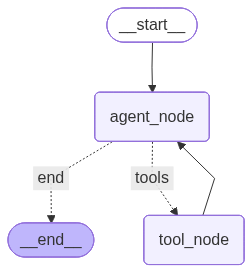

In [57]:
# pass the initial State
workflow = StateGraph(State)

tools = [append_vibes]

# a ToolNode execute the last tools requested in state.messages (its langgraph property)
# and append result to the messages array itself
tool_node = ToolNode(tools)

# Crete the nodes
workflow.add_node("agent_node", agent_node)
workflow.add_node("tool_node", tool_node)

# START NODE
workflow.add_edge(START, "agent_node")
# the EDGE is a conditional edge
workflow.add_conditional_edges(
        source = "agent_node",
        path = tool_router,
        path_map = {
                "tools": "tool_node",
                "end": END,
        }
)
# END NODE
workflow.add_edge("tool_node", "agent_node")

graph = workflow.compile()
display(Image(graph.get_graph().draw_mermaid_png()))

In [58]:
tool_description = get_tool_descriptions(tools)
initial_state = {
        "message": "My vibe is what: ",
        "available_tools": tool_description,
}
result = graph.invoke(initial_state)
result

{'messages': [AIMessage(content='Let me add some vibes to your query!', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'My vibe is what', 'vibe': '✨ cosmic energy meets late-night contemplation with a sprinkle of mysterious wanderlust 🌙'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[]),
  ToolMessage(content='My vibe is what ✨ cosmic energy meets late-night contemplation with a sprinkle of mysterious wanderlust 🌙', name='append_vibes', tool_call_id='call_0'),
  AIMessage(content='Let me add some vibes to your query!', additional_kwargs={}, response_metadata={}, tool_calls=[{'name': 'append_vibes', 'args': {'query': 'My vibe is what', 'vibe': '✨ mysterious and contemplative energy ✨'}, 'id': 'call_0', 'type': 'tool_call'}], invalid_tool_calls=[])],
 'message': 'My vibe is what: ',
 'iteration': 2,
 'answer': 'Let me add some vibes to your query!',
 'available_tools': [{'name': 'append_vibes',
   'description': 'Takes in 